# データサイエンス特論 第7回 演習課題
青山学院大学大学院 理工学研究科 理工学専攻 知能情報コース 修士1年 35626302 森下剛

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#### 演習問題1-1の回答

In [60]:
n11 = 37
n12 = 13
n21 = 23
n22 = 17

row1 = n11 + n12
row2 = n21 + n22
col1 = n11 + n21
col2 = n12 + n22
total = n11 + n12 + n21 + n22

e11 = row1 * col1 / total
e12 = row1 * col2 / total
e21 = row2 * col1 / total
e22 = row2 * col2 / total

print(f"為替上昇 × 株価上昇 の期待度数: {e11}")
print(f"為替上昇 × 株価下降 の期待度数: {e12}")
print(f"為替下降 × 株価上昇 の期待度数: {e21}")
print(f"為替下降 × 株価下降 の期待度数: {e22}")


為替上昇 × 株価上昇 の期待度数: 33.333333333333336
為替上昇 × 株価下降 の期待度数: 16.666666666666668
為替下降 × 株価上昇 の期待度数: 26.666666666666668
為替下降 × 株価下降 の期待度数: 13.333333333333334


#### 演習問題1-2の回答

In [61]:
chi2_yates = (abs(n11 - e11) - 0.5) ** 2 / e11 + (abs(n12 - e12) - 0.5) ** 2 / e12 + (abs(n21 - e21) - 0.5) ** 2 / e21 + (abs(n22 - e22) - 0.5) ** 2 / e22

print(f"イエーツの補正を用いた値: {chi2_yates}")


イエーツの補正を用いた値: 2.0306249999999997


#### 演習問題1-3の回答

自由度: 1
イエーツの補正を用いた値: 2.0306249999999997
上側 5.0% 点（棄却域の境界）: 3.8414588206941205


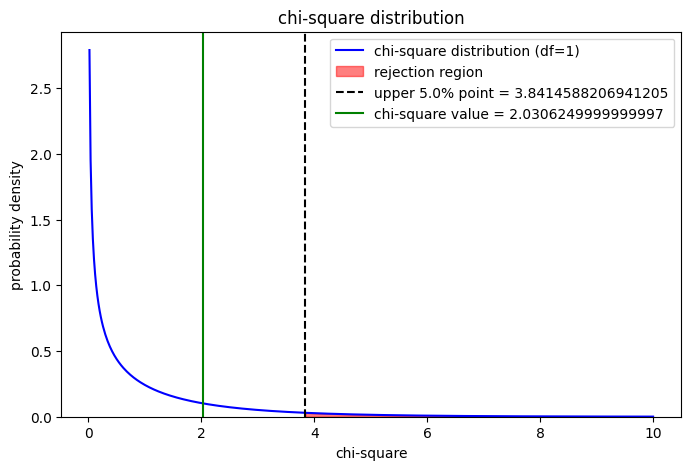

In [62]:
df = (2 - 1) * (2 - 1)
alpha = 0.05
critical_value = stats.chi2.ppf(1 - alpha, df)

print(f"自由度: {df}")
print(f"イエーツの補正を用いた値: {chi2_yates}")
print(f"上側 {alpha * 100}% 点（棄却域の境界）: {critical_value}")

x = np.linspace(0, 10, 500)
y = stats.chi2.pdf(x, df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, color="blue", label=f"chi-square distribution (df={df})")

x_reject = np.linspace(critical_value, 10, 300)
ax.fill_between(x_reject, stats.chi2.pdf(x_reject, df), color="red", alpha=0.5, label="rejection region")

ax.axvline(critical_value, color="black", linestyle="--", label=f"upper {alpha * 100}% point = {critical_value}")
ax.axvline(chi2_yates, color="green", linestyle="-", label=f"chi-square value = {chi2_yates}")

ax.set_xlabel("chi-square")
ax.set_ylabel("probability density")
ax.set_title("chi-square distribution")
ax.set_ylim(bottom=0)
ax.legend()
plt.show()


p値が有意水準0.05より大きいため、帰無仮説は棄却できず、株価と為替の上下動が独立でないとは言えない。

#### 演習課題1-4の回答

SciPyのchi2_contingency()関数

2つ以上のカテゴリ変数間に関連性があるか（独立性の検定）を調べるためのカイ二乗検定関数

引数一覧：
- observed: 観測度数を並べた分割表の2次元配列で、必須項目である。
- correction: イエーツの連続補正を行うかどうかを指定する。
- lambda_: 検定統計量の種類を指定する引数である。
- method: 漸近的なカイ二乗近似ではなく、並べ替え検定などの方法でp値を計算したい場合にしていする引数である。

#### 演習課題1-5の回答

In [63]:
observed_table = np.array([[n11, n12],
                           [n21, n22]])

chi2_value, p_value, dof, expected_table = stats.chi2_contingency(observed_table, correction=True)

alpha = 0.05

print(f"カイ二乗値: {chi2_value}")
print(f"p 値: {p_value}")
print(f"自由度: {dof}")
print("期待度数の表:")
print(expected_table)


カイ二乗値: 2.0306249999999997
p 値: 0.15415720110413975
自由度: 1
期待度数の表:
[[33.33333333 16.66666667]
 [26.66666667 13.33333333]]


演習課題1-3と同じ結果を得ることができた。

#### 演習問題2-1の回答

標本サイズ n: 150
相関係数 r: -0.11756978413300208
自由度: 148
統計量 t0: 1.44028708889513
上側 2.5% 点（棄却域の境界）: 1.9761224936137445


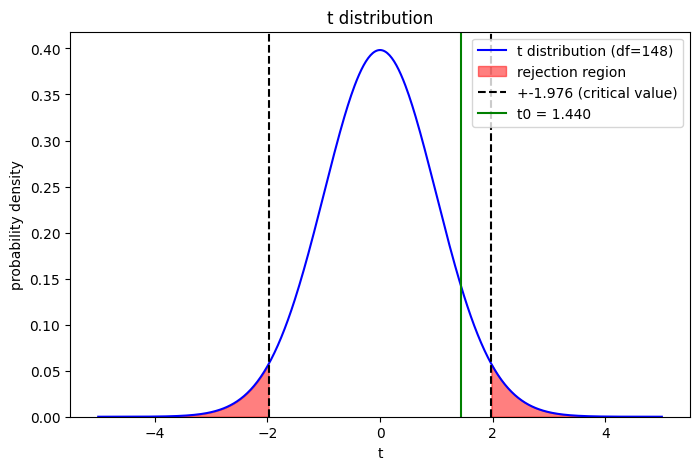

In [64]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
sepal_length = iris.frame["sepal length (cm)"]
sepal_width = iris.frame["sepal width (cm)"]

n = len(sepal_length)
r = np.corrcoef(sepal_length, sepal_width)[0, 1]

t0 = abs(r) * np.sqrt(n - 2) / np.sqrt(1 - r ** 2)

df = n - 2
alpha = 0.05
critical_value = stats.t.ppf(1 - alpha / 2, df)

print(f"標本サイズ n: {n}")
print(f"相関係数 r: {r}")
print(f"自由度: {df}")
print(f"統計量 t0: {t0}")
print(f"上側 {alpha / 2 * 100}% 点（棄却域の境界）: {critical_value}")

x = np.linspace(-5, 5, 500)
y = stats.t.pdf(x, df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, color="blue", label=f"t distribution (df={df})")

x_reject_right = np.linspace(critical_value, 5, 300)
ax.fill_between(x_reject_right, stats.t.pdf(x_reject_right, df), color="red", alpha=0.5, label="rejection region")
x_reject_left = np.linspace(-5, -critical_value, 300)
ax.fill_between(x_reject_left, stats.t.pdf(x_reject_left, df), color="red", alpha=0.5)

ax.axvline(critical_value, color="black", linestyle="--", label=f"+-{critical_value:.3f} (critical value)")
ax.axvline(-critical_value, color="black", linestyle="--")
ax.axvline(t0, color="green", linestyle="-", label=f"t0 = {t0:.3f}")

ax.set_xlabel("t")
ax.set_ylabel("probability density")
ax.set_title("t distribution")
ax.set_ylim(bottom=0)
ax.legend()
plt.show()


統計量 t0 が両側の棄却域に入らないため、帰無仮説は棄却できず、sepal length と sepal width の間に相関があるとは言えない。

#### 演習問題2-2の回答

SciPyのpearsonr()関数

2つの変量間のピアソンの積率相関係数を求め、相関がない（無相関）という帰無仮説に対する検定のp値を計算する関数

引数一覧：
- x: 相関係数を求める一方の変量のデータ列で、必須項目である。
- y: 相関係数を求めるもう一方の変量のデータ列で、x と同じ長さが必要な必須項目である。
- alternative: 対立仮説の種類を指定する引数で、両側検定や片側検定を切り替える。既定は両側検定である。
- method: p値の計算方法を指定する引数で、通常の理論分布による方法のほか、並べ替え検定やブートストラップ法を指定することができる。

#### 演習問題2-3の回答

In [65]:
r_value, p_value = stats.pearsonr(sepal_length, sepal_width)

alpha = 0.05

print(f"相関係数 r: {r_value}")
print(f"p 値: {p_value}")


相関係数 r: -0.11756978413300202
p 値: 0.15189826071144766


演習問題2-1と同じ結果を得ることができた。